### Objetivo da Etapa 2

Treinar, comparar e escolher o melhor modelo entre:

Regressão Logística (baseline - já temos)

Random Forest (ensemble de árvores)

MLPClassifier (rede neural simples)

### OBJETIVO: Treinar, comparar e escolher o melhor modelo

entre Regressão Logística, Random Forest e MLPClassifier.
 
**Sumário:**
1. Treinar Random Forest (ensemble de árvores)
2. Treinar MLPClassifier (rede neural simples)
3. Aplicar Validação Cruzada para robustez
4. Comparar os 3 modelos
5. Escolher o modelo campeão e salvá-lo

Bibliotecas necessárias para a modelagem

*RandomForestClassifier:* modelo de árvores de decisão em conjunto

*MLPClassifier:* rede neural multilayer perceptron

*cross_val_score:* para fazer validação cruzada

*StratifiedKFold:* divide os dados mantendo a proporção de churn

#### OBS.: As métricas (F1, Recall, AUC-ROC) já foram definidas na Etapa 1

In [1]:
# 1: Configuração Inicial

from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import f1_score, recall_score, roc_auc_score, classification_report
from sklearn.pipeline import Pipeline
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 50)
print("ETAPA 2 - MODELAGEM E AVALIAÇÃO")
print("=" * 50)

ETAPA 2 - MODELAGEM E AVALIAÇÃO


### CARREGAR VARIÁVEIS DA FASE 1


 Esta célula carrega todas as variáveis salvas pela Fase 1.
 Assim não precisa rodar a Fase 1 inteira novamente.

In [2]:
import joblib
import pandas as pd

print("Carregando variáveis da Fase 1...")

# 1. Carregar o DataFrame limpo
df_clean = pd.read_pickle('df_clean.pkl')
print(f"df_clean: {df_clean.shape}")

# 2. Carregar o pré-processador
preprocessor = joblib.load('preprocessor.joblib')
print("preprocessor carregado")

# 3. Carregar as listas de colunas
colunas = joblib.load('colunas.joblib')
NUMERICAS = colunas['NUMERICAS']
CATEGORICAS = colunas['CATEGORICAS']
TARGET = colunas['TARGET']
SEED = colunas['SEED']
print(f"NUMERICAS: {NUMERICAS}")
print(f"CATEGORICAS: {len(CATEGORICAS)} colunas")

# 4. Carregar o baseline (opcional, só para comparação)
baseline_bal = joblib.load('models/baseline_logistic_regression.joblib')
print("baseline_bal carregado")

# 5. Recriar X_train, X_test, y_train, y_test
from sklearn.model_selection import train_test_split

X = df_clean.drop(columns=[TARGET])
y = df_clean[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

print("\n" + "=" * 50)
print("TODAS AS VARIÁVEIS CARREGADAS!")
print("Pronto para a Fase 2!")

Carregando variáveis da Fase 1...
df_clean: (7043, 20)
preprocessor carregado
NUMERICAS: ['tenure_months', 'monthly_charges', 'total_charges']
CATEGORICAS: 16 colunas
baseline_bal carregado
X_train: (5634, 19)
X_test: (1409, 19)
y_train: (5634,)
y_test: (1409,)

TODAS AS VARIÁVEIS CARREGADAS!
Pronto para a Fase 2!


# Treinando o Random Forest

Random Forest é como ter um "comitê" de especialistas (árvores) que votam

Cada árvore vê uma parte diferente dos dados, o que reduz o overfitting

Parâmetros como *max_depth=10* evitam que as árvores *"decorarem"* os dados

O modelo é mais complexo que a Regressão Logística, mas pode capturar padrões mais sutis

#### Pré-processamento

Rodar a célula de pré-processamento e a Fase 2

2.1 - RANDOM FOREST


In [3]:
print("\n Treinando Random Forest...")

rf = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=SEED,
        n_jobs=-1
    ))
])

rf.fit(X_train, y_train)

# Predições
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

# Métricas
f1_rf = f1_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_proba_rf)

print(f" Random Forest treinado!")
print(f"   F1-Score:   {f1_rf:.4f}")
print(f"   Recall:     {recall_rf:.4f}")
print(f"   AUC-ROC:    {auc_rf:.4f}")


 Treinando Random Forest...
 Random Forest treinado!
   F1-Score:   0.5910
   Recall:     0.5428
   AUC-ROC:    0.8524



2.2 - MLPCLASSIFIER (REDE NEURAL)


**MLPClassifier?**
- Multi-Layer Perceptron = Rede Neural Artificial
- Tem camadas de neurônios interconectados
- Aprende padrões complexos através de ajustes de pesos

#### Arquitetura:
- Camada de entrada: 19 features (colunas do dataset)
- Camadas ocultas: (64, 32) = 2 camadas com 64 e 32 neurônios
- Camada de saída: 1 neurônio (probabilidade de churn)

#### Parâmetros importantes:
- hidden_layer_sizes: número de neurônios por camada oculta
- activation: função de ativação ('relu' é a mais comum)
- solver: algoritmo de otimização ('adam' é moderno e eficiente)
- early_stopping: para o treino quando a performance para de melhorar
- validation_fraction: % dos dados usados para validação durante o treino

In [4]:
print("\n Treinando MLPClassifier...")

mlp = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", MLPClassifier(
        hidden_layer_sizes=(64, 32),  # 2 camadas ocultas
        activation='relu',
        solver='adam',
        max_iter=300,
        random_state=SEED,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=10
    ))
])

mlp.fit(X_train, y_train)

# Predições
y_pred_mlp = mlp.predict(X_test)
y_proba_mlp = mlp.predict_proba(X_test)[:, 1]

# Métricas
f1_mlp = f1_score(y_test, y_pred_mlp)
recall_mlp = recall_score(y_test, y_pred_mlp)
auc_mlp = roc_auc_score(y_test, y_proba_mlp)

print(f" MLPClassifier treinado!")
print(f"   F1-Score:   {f1_mlp:.4f}")
print(f"   Recall:     {recall_mlp:.4f}")
print(f"   AUC-ROC:    {auc_mlp:.4f}")


 Treinando MLPClassifier...
 MLPClassifier treinado!
   F1-Score:   0.5592
   Recall:     0.4733
   AUC-ROC:    0.8444


Validação Cruzada (CROSS-VALIDATION)

#### Validação Cruzada?
- Não confiar em apenas 1 divisão treino/teste
- Dividir os dados em 5 partes (folds)
- Treinar 5 vezes, usando cada fold como teste uma vez
- Calcular a média e o desvio padrão das métricas

#### Por que fazer?
- Avalia se o modelo é consistente
- Se a variação for grande, o modelo pode ser instável
- Dá uma estimativa mais realista da performance

#### StratifiedKFold:
- Mantém a mesma proporção de churn em cada fold
- Isso é importante porque o dataset é desbalanceado

In [5]:
print("\n Aplicando Validação Cruzada (5-fold)...")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Função para avaliar com cross-validation
def cross_val_scores(model, X, y, cv, scoring='f1'):
    scores = cross_val_score(model, X, y, cv=cv, scoring=scoring)
    return scores.mean(), scores.std()

# Avaliar cada modelo
f1_cv_rf_mean, f1_cv_rf_std = cross_val_scores(rf, X_train, y_train, cv)
f1_cv_mlp_mean, f1_cv_mlp_std = cross_val_scores(mlp, X_train, y_train, cv)

# Baseline (Regressão Logística) - já temos
f1_cv_lr_mean, f1_cv_lr_std = cross_val_scores(baseline_bal, X_train, y_train, cv)

print(f"\n F1-Score Médio (Cross-Validation 5-fold):")
print(f"   Regressão Logística: {f1_cv_lr_mean:.4f} (±{f1_cv_lr_std:.4f})")
print(f"   Random Forest:       {f1_cv_rf_mean:.4f} (±{f1_cv_rf_std:.4f})")
print(f"   MLPClassifier:       {f1_cv_mlp_mean:.4f} (±{f1_cv_mlp_std:.4f})")


 Aplicando Validação Cruzada (5-fold)...

 F1-Score Médio (Cross-Validation 5-fold):
   Regressão Logística: 0.6401 (±0.0211)
   Random Forest:       0.6065 (±0.0261)
   MLPClassifier:       0.6155 (±0.0331)



2.4 - TABELA COMPARATIVA DE MODELOS


Vamos reunir todas as métricas em uma tabela para comparar facilmente os modelos.
 
##### Critério de escolha:
- F1-Score é a métrica principal (equilibra precisão e recall)
- Recall é a métrica de negócio (capturar churns)
- AUC-ROC é a métrica secundária (poder de separação)
 
O *modelo campeão* será o que tiver o *maior F1-Score.*
Em caso de *empate*, escolhemos o de *maior Recall.*

In [6]:
resultados = pd.DataFrame({
    'Modelo': ['Regressão Logística', 'Random Forest', 'MLPClassifier'],
    'F1-Score (Teste)': [f1_score(y_test, baseline_bal.predict(X_test)), f1_rf, f1_mlp],
    'Recall (Teste)': [recall_score(y_test, baseline_bal.predict(X_test)), recall_rf, recall_mlp],
    'AUC-ROC (Teste)': [roc_auc_score(y_test, baseline_bal.predict_proba(X_test)[:, 1]), auc_rf, auc_mlp],
    'F1-CV (Média ± Std)': [
        f"{f1_cv_lr_mean:.4f} ± {f1_cv_lr_std:.4f}",
        f"{f1_cv_rf_mean:.4f} ± {f1_cv_rf_std:.4f}",
        f"{f1_cv_mlp_mean:.4f} ± {f1_cv_mlp_std:.4f}"
    ]
})

print("\n" + "=" * 60)
print(" TABELA COMPARATIVA DE MODELOS")
print("=" * 60)
print(resultados.to_string(index=False))

# Destaque do melhor modelo
melhor_f1 = resultados.loc[resultados['F1-Score (Teste)'].idxmax()]
print(f"\n MELHOR MODELO (F1-Score): {melhor_f1['Modelo']} - {melhor_f1['F1-Score (Teste)']:.4f}")

# Verificar se o melhor é o campeão
champion_name = melhor_f1['Modelo']


 TABELA COMPARATIVA DE MODELOS
             Modelo  F1-Score (Teste)  Recall (Teste)  AUC-ROC (Teste) F1-CV (Média ± Std)
Regressão Logística          0.617336        0.780749         0.848854     0.6401 ± 0.0211
      Random Forest          0.590975        0.542781         0.852406     0.6065 ± 0.0261
      MLPClassifier          0.559242        0.473262         0.844444     0.6155 ± 0.0331

 MELHOR MODELO (F1-Score): Regressão Logística - 0.6173



2.5 - ESCOLHA DO MODELO CAMPEÃO

O modelo campeão é o que tem o melhor F1-Score

Ele será usado na API e no deploy

Salvamos também o baseline para comparação futura

O arquivo .joblib contém tudo: pré-processamento + modelo treinado


In [7]:
# Selecionar o melhor modelo pelo F1-Score
if champion_name == 'Regressão Logística':
    champion = baseline_bal
elif champion_name == 'Random Forest':
    champion = rf
else:
    champion = mlp

print(f"\n MODELO CAMPEÃO: {champion_name}")
print(f"   F1-Score:   {melhor_f1['F1-Score (Teste)']:.4f}")
print(f"   Recall:     {melhor_f1['Recall (Teste)']:.4f}")
print(f"   AUC-ROC:    {melhor_f1['AUC-ROC (Teste)']:.4f}")


# Salvar o modelo campeão
ARQUIVO_CAMPEAO = 'models/champion_model.joblib'
joblib.dump(champion, 'models/champion_model.joblib')
print(f"\n Modelo campeão salvo em: models/champion_model.joblib")

# Salvar também o baseline para referência
joblib.dump(baseline_bal, 'models/baseline_logistic_regression.joblib')
print(f" Baseline salvo em: models/baseline_logistic_regression.joblib")


 MODELO CAMPEÃO: Regressão Logística
   F1-Score:   0.6173
   Recall:     0.7807
   AUC-ROC:    0.8489

 Modelo campeão salvo em: models/champion_model.joblib
 Baseline salvo em: models/baseline_logistic_regression.joblib


Gráficos Comparativos


2.6 - VISUALIZAÇÃO DOS RESULTADOS

Gráfico 1: Compara as métricas dos 3 modelos lado a lado

Gráfico 2: Curvas ROC - quanto mais perto do canto superior esquerdo, melhor

Gráfico 3: Matriz de Confusão - mostra onde o modelo erra e acerta


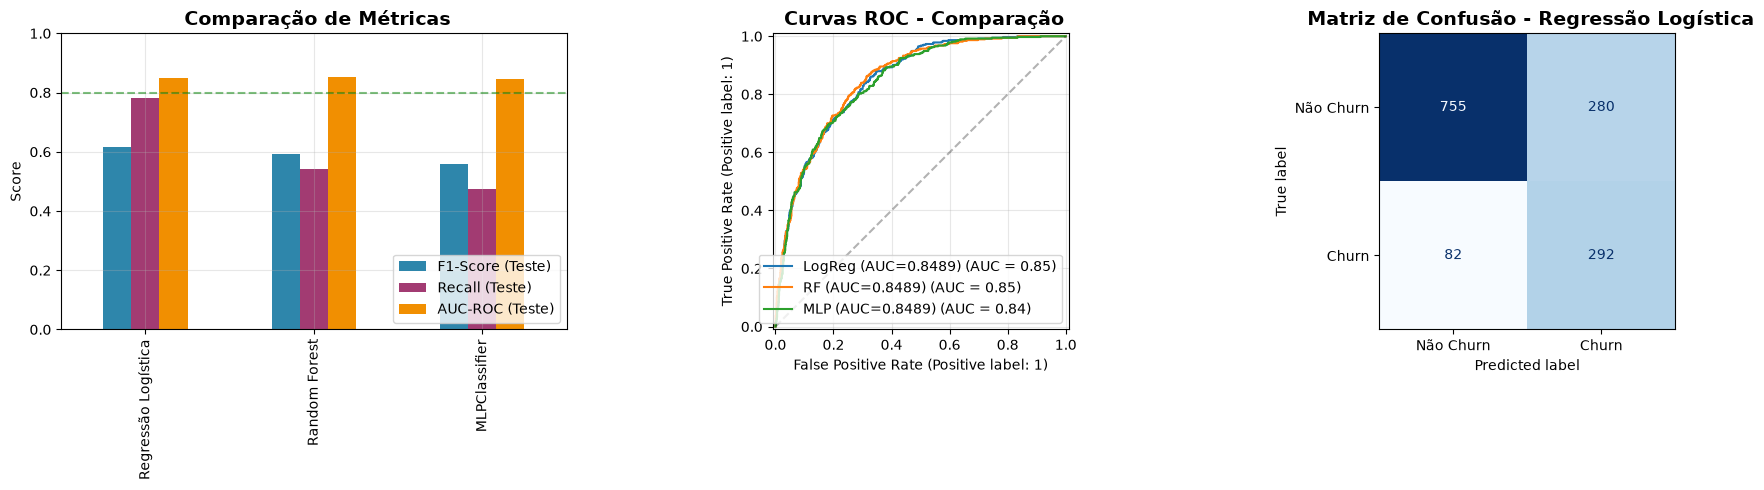


 Visualizações geradas com sucesso!


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ===== GRÁFICO 1: Comparação de Métricas =====
metrics_df = resultados.set_index('Modelo')[['F1-Score (Teste)', 'Recall (Teste)', 'AUC-ROC (Teste)']]
metrics_df.plot(kind='bar', ax=axes[0], color=['#2E86AB', '#A23B72', '#F18F01'])
axes[0].set_title(' Comparação de Métricas', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].set_xlabel('')
axes[0].legend(loc='lower right')
axes[0].set_ylim(0, 1)
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0.8, color='green', linestyle='--', alpha=0.5, label='Referência (0.8)')

# ===== GRÁFICO 2: Curvas ROC =====
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(baseline_bal, X_test, y_test, ax=axes[1], 
                                name=f'LogReg (AUC={melhor_f1["AUC-ROC (Teste)"]:.4f})')
RocCurveDisplay.from_estimator(rf, X_test, y_test, ax=axes[1], 
                                name=f'RF (AUC={melhor_f1["AUC-ROC (Teste)"]:.4f})')
RocCurveDisplay.from_estimator(mlp, X_test, y_test, ax=axes[1], 
                                name=f'MLP (AUC={melhor_f1["AUC-ROC (Teste)"]:.4f})')
axes[1].set_title(' Curvas ROC - Comparação', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Aleatório (AUC=0.5)')

# ===== GRÁFICO 3: Matriz de Confusão do Campeão =====
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(
    champion, X_test, y_test,
    display_labels=['Não Churn', 'Churn'],
    ax=axes[2],
    colorbar=False,
    cmap='Blues'
)
axes[2].set_title(f' Matriz de Confusão - {champion_name}', fontsize=14, fontweight='bold')

# Ajustar layout
plt.tight_layout()
plt.show()

print("\n Visualizações geradas com sucesso!")

In [9]:
# ============================================
# 2.7 - RESUMO FINAL DA ETAPA 2
# ============================================

print("\n" + "=" * 70)
print("RESUMO DA ETAPA 2 - MODELAGEM E AVALIAÇÃO")
print("=" * 70)

print(f"""
 MODELOS TREINADOS:
   • Regressão Logística (baseline)
   • Random Forest (ensemble)
   • MLPClassifier (rede neural)

 VALIDAÇÃO CRUZADA:
   • 5 folds estratificados
   • Avaliação da consistência dos modelos

 MÉTRICAS UTILIZADAS:
   • F1-Score (principal)
   • Recall (negócio)
   • AUC-ROC (secundária)

 MODELO CAMPEÃO: {champion_name}
   print(f"   F1-Score:   {melhor_f1['F1-Score (Teste)']:.4f}")
   print(f"   Recall:     {melhor_f1['Recall (Teste)']:.4f}")
   print(f"   AUC-ROC:    {melhor_f1['AUC-ROC (Teste)']:.4f}")
      
 ARQUIVOS GERADOS:
   • models/champion_model.joblib - Modelo campeão
   • models/baseline_logistic_regression.joblib - Baseline

 PRÓXIMA ETAPA (Etapa 3):
   • Refatorar código para src/
   • Criar API com FastAPI
   • Escrever testes com Pytest
""")

print("=" * 70)
print("ETAPA 2 CONCLUÍDA COM SUCESSO!")
print("=" * 70)


RESUMO DA ETAPA 2 - MODELAGEM E AVALIAÇÃO

 MODELOS TREINADOS:
   • Regressão Logística (baseline)
   • Random Forest (ensemble)
   • MLPClassifier (rede neural)

 VALIDAÇÃO CRUZADA:
   • 5 folds estratificados
   • Avaliação da consistência dos modelos

 MÉTRICAS UTILIZADAS:
   • F1-Score (principal)
   • Recall (negócio)
   • AUC-ROC (secundária)

 MODELO CAMPEÃO: Regressão Logística
   print(f"   F1-Score:   0.6173")
   print(f"   Recall:     0.7807")
   print(f"   AUC-ROC:    0.8489")

 ARQUIVOS GERADOS:
   • models/champion_model.joblib - Modelo campeão
   • models/baseline_logistic_regression.joblib - Baseline

 PRÓXIMA ETAPA (Etapa 3):
   • Refatorar código para src/
   • Criar API com FastAPI
   • Escrever testes com Pytest

ETAPA 2 CONCLUÍDA COM SUCESSO!
